# Pandas tutorijal baziran na "TED Talks" dataset-u

Ovaj tutorijal je zasnovan na ["TED Talks" skupu podataka](https://www.kaggle.com/datasets/rounakbanik/ted-talks), koji je raspoloživ na [Kaggle sajtu](https://www.kaggle.com/datasets), pod [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) licencom.<br>
Tutorijal je delimično zasnovan na ["Data Science Best Practices with pandas"](https://github.com/justmarkham/pycon-2019-tutorial) tutorijalu, kojeg je predstavio Kevin Markham u maju 2019. godine na PyCon2019.

## 1. Učitavanje potrebnih biblioteka

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

Nekada je potrebno da znate verziju pandasa koju koristite, kao na primer, kada želite da pogledate pandas dokumentaciju. Verziju možete da saznate preko sledeće komande:

In [2]:
pd.__version__

'2.1.0'

## 2. Učitavanje TED talks dataset-a i upoznavanje sa njegovim sadržajem

Preuzmite `ted.csv` fajl sa Kaggle sajta ([direktan link](https://www.kaggle.com/datasets/rounakbanik/ted-talks)) i sačuvajte na lokalnom računaru.

In [3]:
ted = pd.read_csv(Path.cwd() / 'data' / 'ted.csv')
ted.head()

,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


In [4]:
ted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   comments            2550 non-null   int64 
 1   description         2550 non-null   object
 2   duration            2550 non-null   int64 
 3   event               2550 non-null   object
 4   film_date           2550 non-null   int64 
 5   languages           2550 non-null   int64 
 6   main_speaker        2550 non-null   object
 7   name                2550 non-null   object
 8   num_speaker         2550 non-null   int64 
 9   published_date      2550 non-null   int64 
 10  ratings             2550 non-null   object
 11  related_talks       2550 non-null   object
 12  speaker_occupation  2544 non-null   object
 13  tags                2550 non-null   object
 14  title               2550 non-null   object
 15  url                 2550 non-null   object
 16  views               2550

### 2.1 Nedostajuće vrednosti

In [5]:
ted.isna().sum()

comments              0
description           0
duration              0
event                 0
film_date             0
languages             0
main_speaker          0
name                  0
num_speaker           0
published_date        0
ratings               0
related_talks         0
speaker_occupation    6
tags                  0
title                 0
url                   0
views                 0
dtype: int64

Želimo da proverimo ko su govornici sa nedostajućim zanimanjem (speaker_occupation) i ukoliko je moguće da pronađemo njihovo zanimanje na osnovu drugih zapisa (u slučaju da su održali više govora).

In [6]:
no_occupation_speakers = ted.loc[ted.speaker_occupation.isna(), 'main_speaker']

In [7]:
no_occupation_speakers = no_occupation_speakers.values.tolist()
no_occupation_speakers

['Sonaar Luthra',
 'Rick Falkvinge',
 'Gary Kovacs',
 'Ryan Holladay',
 'Brian Dettmer',
 'Boniface Mwangi']

In [8]:
ted.loc[ted.main_speaker.isin(no_occupation_speakers), ['main_speaker', 'speaker_occupation']]

,main_speaker,speaker_occupation
1113,Sonaar Luthra,NaN
1192,Rick Falkvinge,NaN
1220,Gary Kovacs,NaN
1656,Ryan Holladay,NaN
1911,Brian Dettmer,NaN
1949,Boniface Mwangi,NaN


S obzirom da smo utvrdili da ne postoje dodatni zapisi na osnovu kojih možemo da popunimo nedostajuća zanimanja, zamenićemo **"NaN"** sa **"unknown"**.

In [9]:
ted.speaker_occupation = (
    ted.speaker_occupation.apply(lambda occupation: "unknown" if occupation is np.NaN else occupation))

In [10]:
ted.speaker_occupation.isna().sum()

0

### 2.2 Transformacija kolona

Potrebno je transformisati datum snimanja (**film_date**) i datum objavljivanja (**published_date**) u **datetime** tip

Prvo, ispitajte vrednosti kolona `film_date` i `published_date` na manjem uzorku:

In [11]:
ted[['film_date', 'published_date']].sample(5)

,film_date,published_date
1255,1330560000,1339171010
1059,1305072000,1321028091
2254,1455494400,1470667902
780,1284940800,1285836660
91,1044144000,1176162180


Možemo da primetimo da su oba datuma data u obliku **Unix epoch time**, koji predstavlja broj sekundi koje su protekle od 1. januara 1970. godine. To je uobičajeni način predstavljanja datuma i vremena u većini, ako ne i svim programskim jezicima. Više o Unix epoch time možete da saznate na: https://www.epochconverter.com/.<br>

Počećemo sa pretvaranjem kolone `film_date` u `datetime` tip.

In [12]:
try:
    ted['filming_date'] = pd.to_datetime(ted['film_date'], unit='s', origin='unix')
except ValueError as err:
    print(err)

In [13]:
ted.filming_date.head()

0   2006-02-25
1   2006-02-25
2   2006-02-24
3   2006-02-26
4   2006-02-22
Name: filming_date, dtype: datetime64[ns]

Isto ćemo uraditi za `published_date`

In [14]:
ted['publication_date'] = pd.to_datetime(ted['published_date'], unit='s', origin='unix')

In [15]:
ted.publication_date.sample(5)

1508   2013-05-20 15:23:20
2518   2017-08-22 20:00:25
933    2011-05-11 14:14:00
1426   2013-01-31 16:02:17
1645   2013-12-17 15:59:58
Name: publication_date, dtype: datetime64[ns]

### 2.3 Brisanje kolona koje više nisu potrebne

In [16]:
ted.drop(columns=['film_date', 'published_date'], inplace=True)

In [17]:
ted.columns.tolist()

['comments',
 'description',
 'duration',
 'event',
 'languages',
 'main_speaker',
 'name',
 'num_speaker',
 'ratings',
 'related_talks',
 'speaker_occupation',
 'tags',
 'title',
 'url',
 'views',
 'filming_date',
 'publication_date']

### 2.4 Promena naziva kolona

Najjednostavniji način za promenu naziva kolone je korišćenje **rename()** metode. Potrebno je da joj se prosledi rečnik, u kom su ključevi stari nazivi kolona, dok su vrednosti novi nazivi. Takođe, potrebno je postaviti `axis` parametar na 'columns'.

Na primer, možemo promeniti nazive kolona 'comments' i 'views' u 'comment_count' i 'view_count', respektivno.

In [18]:
ted.rename({'comments':'comment_count', 'views':'view_count'}, axis='columns', inplace=True)

In [19]:
ted.columns.tolist()

['comment_count',
 'description',
 'duration',
 'event',
 'languages',
 'main_speaker',
 'name',
 'num_speaker',
 'ratings',
 'related_talks',
 'speaker_occupation',
 'tags',
 'title',
 'url',
 'view_count',
 'filming_date',
 'publication_date']

## Zadatak 1: Izračunajte i prikažite grafikonom broj govora koji su održani svake godine

Kako biste ovo uradili, potrebno je da izdvojite godinu iz datuma snimanja.

In [20]:
ted['event_year'] = ted['filming_date'].dt.year
ted[['filming_date', 'event_year']].head()

,filming_date,event_year
0,2006-02-25,2006
1,2006-02-25,2006
2,2006-02-24,2006
3,2006-02-26,2006
4,2006-02-22,2006


Zatim izračunajte broj govora po godini

In [21]:
ted.event_year.value_counts()

event_year
2013    270
2011    270
2010    267
2012    267
2016    246
2015    239
2014    237
2009    232
2007    114
2017     98
2008     84
2005     66
2006     50
2004     33
2003     33
2002     27
1998      6
2001      5
1983      1
1972      1
1990      1
1994      1
1984      1
1991      1
Name: count, dtype: int64

Možete da primetite da je rezultujuća pandas serija (pd.Series) podrazumevano sortirana u opadajućem redosledu vrednosti. To bi nam odgovaralo ukoliko nas zanimaju godine sa najvećim/najmanjim brojem govora.<br>
Međutim, pošto želimo da iscrtamo grafik koji pokazuje broj govora godišnje, potreban nam je broj govora poređan na osnovu godina. Iz tog razloga vršimo sortiranje na osnovu indeksa:

In [22]:
talks_per_year = ted.event_year.value_counts()
talks_per_year.sort_index(inplace=True)

In [23]:
talks_per_year

event_year
1972      1
1983      1
1984      1
1990      1
1991      1
1994      1
1998      6
2001      5
2002     27
2003     33
2004     33
2005     66
2006     50
2007    114
2008     84
2009    232
2010    267
2011    270
2012    267
2013    270
2014    237
2015    239
2016    246
2017     98
Name: count, dtype: int64

Sada možemo da kreiramo grafikon koji prikazuje broj govora tokom godina

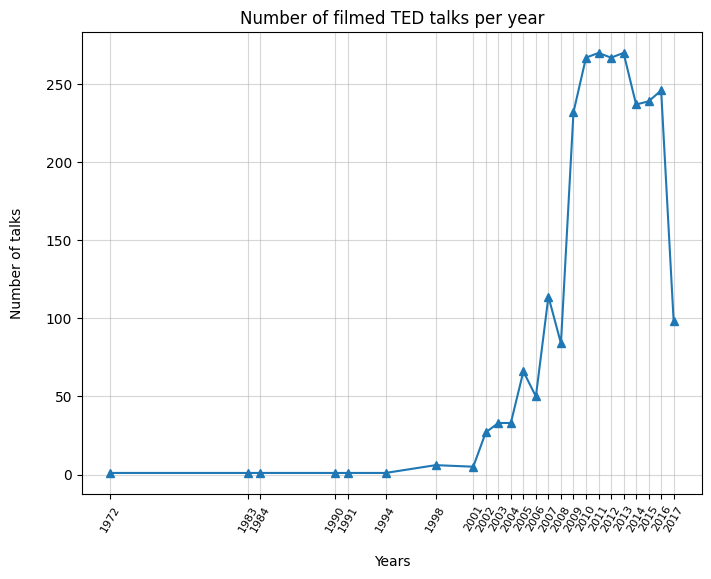

In [24]:
x = talks_per_year.index
y = talks_per_year.values

_, ax = plt.subplots(figsize=(8,6))
ax.plot(x, y, marker="^")

years = talks_per_year.index.tolist()
ax.set_xticks(years)
ax.set_xlabel("\nYears")
ax.tick_params(axis='x', labelrotation=60, labelsize=8)
ax.set_ylabel("Number of talks\n")
ax.grid(visible=True, alpha=0.5)
ax.set_title("Number of filmed TED talks per year")

plt.show()

## Zadatak 2: Koji TED događaj je privukao najviše pažnje?

Podrazmevajte broj pregleda kao pokazatelj atraktivnosti događaja.

S obzirom da broj TED govora varira od jednog do drugog TED događaja, ne bi bilo korektno da se za procenu "pažnje" jednog TED događaja računa ukupan broj pregleda po događaju. Iz tog razloga razmatraćemo prosečan broj pregleda po događaju.

In [25]:
ted.groupby('event').view_count.mean().sort_values(ascending=False)

event
TEDxPuget Sound           34309432.0
TEDxHouston               16140250.5
TEDxBloomington            9484259.5
TEDxCreativeCoast          8444981.0
TEDxNorrkoping             6569493.0
                             ...    
TEDxNASA@SiliconValley      155895.0
AORN Congress               149818.0
TEDxWaterloo                138812.0
TEDxIslay                   120274.0
The Do Lectures             112321.0
Name: view_count, Length: 355, dtype: float64

Može se desiti da neki od ovih događaja ima visoku srednju vrednost pregleda zahvaljujući malom broju veoma popularnih govora ili čak samo jednom veoma popularnom govoru. Iz tog razloga, uzmećemo u obzir i broj govora na svakom događaju.

Kako bi se na grupisane podatke primenilo više funkcija (u ovom slučaju, `mean` i `count`), funkcija **groupby()** može da se proprati funkcijom **agg()**, koja prima listu funkcija koje želimo da primenimo na grupisanim podacima.

In [26]:
ted.groupby('event').view_count.agg(['count', 'mean']).head()

,count,mean
event,,
AORN Congress,1,149818.0
Arbejdsglaede Live,1,971594.0
BBC TV,1,521974.0
Bowery Poetry Club,1,676741.0
Business Innovation Factory,3,304086.0


Rezultat čuvamo u novom okviru podataka(data frame)

In [27]:
events_views = ted.groupby('event').view_count.agg(['count', 'mean'])

In [28]:
events_views.columns = ['talk_count', 'mean_views']

Sada možemo da analiziramo i prosečan broj pregleda i broj govora za svaki događaj

In [29]:
events_views.sort_values(by='mean_views', ascending=False).head(10)

,talk_count,mean_views
event,,
TEDxPuget Sound,1,34309432.0
TEDxHouston,2,16140250.5
TEDxBloomington,2,9484259.5
TEDxCreativeCoast,1,8444981.0
TEDxNorrkoping,1,6569493.0
TEDxUW,1,5917201.0
TEDxLinnaeusUniversity,1,4984884.0
TEDxGoldenGatePark 2012,1,4811180.0
TEDxCHUV,1,4682458.0


Možemo da primetimo da svih 10 događaja koji su u vrhu (na osnovu prosečnih vrednosti) imaju najviše 2 govora.

Da bi proverili je li to generalno tako u ovom dataset-u, proverićemo statistike za broj govora i prosečan broj pregleda po događaju.

In [30]:
events_views.describe()

,talk_count,mean_views
count,355.000000,3.550000e+02
mean,7.183099,1.527689e+06
std,15.265735,2.205832e+06
min,1.000000,1.123210e+05
25%,1.000000,7.594215e+05
50%,2.000000,1.187105e+06
75%,5.000000,1.715774e+06
max,84.000000,3.430943e+07


Kako bismo dobili bolji uvid u popularnije TED događaje, razmotrimo samo one događaje koji imaju broj govora iznad proseka. Uzimajući u obzir veoma iskrivljenu distribuciju (brojevi govora po događaju znatno variraju: od 1 do 84), koristićemo medijanu kao prosečnu vrednost.

In [31]:
avg_talk_cnt = events_views.describe().loc['50%', 'talk_count']

In [32]:
events_views.loc[events_views.talk_count > avg_talk_cnt, :].sort_values(by='mean_views', ascending=False)

,talk_count,mean_views
event,,
TED Talks Education,8,4.375104e+06
TEDGlobal>Geneva,11,3.385408e+06
TED2006,45,3.274345e+06
TEDxManhattanBeach,3,3.251704e+06
TEDSalon NY2013,11,2.861639e+06
...,...,...
TEDxYYC,3,3.699607e+05
Business Innovation Factory,3,3.040860e+05
TEDxPhoenix,4,2.846855e+05


Možemo zaključiti da ako razmatramo sve TED događaje, TEDxPuget Sound je bio najpopularniji (po broju pregleda). Ali, ako uzmemo u obzir samo one TED događaje za koje u dataset-u imamo bar dva govora, najpopularniji je TED Talks Education.

## Zadatak 3: Analiza govora na osnovu njihovih ocena (ratings)

Pogledajmo manji uzorak koji opisuje ocene:

In [33]:
ted.ratings.sample(5)

137     [{'id': 9, 'name': 'Ingenious', 'count': 942},...
1310    [{'id': 9, 'name': 'Ingenious', 'count': 297},...
871     [{'id': 24, 'name': 'Persuasive', 'count': 261...
1080    [{'id': 10, 'name': 'Inspiring', 'count': 787}...
2416    [{'id': 3, 'name': 'Courageous', 'count': 178}...
Name: ratings, dtype: object

In [34]:
ted.ratings[0]

"[{'id': 7, 'name': 'Funny', 'count': 19645}, {'id': 1, 'name': 'Beautiful', 'count': 4573}, {'id': 9, 'name': 'Ingenious', 'count': 6073}, {'id': 3, 'name': 'Courageous', 'count': 3253}, {'id': 11, 'name': 'Longwinded', 'count': 387}, {'id': 2, 'name': 'Confusing', 'count': 242}, {'id': 8, 'name': 'Informative', 'count': 7346}, {'id': 22, 'name': 'Fascinating', 'count': 10581}, {'id': 21, 'name': 'Unconvincing', 'count': 300}, {'id': 24, 'name': 'Persuasive', 'count': 10704}, {'id': 23, 'name': 'Jaw-dropping', 'count': 4439}, {'id': 25, 'name': 'OK', 'count': 1174}, {'id': 26, 'name': 'Obnoxious', 'count': 209}, {'id': 10, 'name': 'Inspiring', 'count': 24924}]"

Iako vrednost 'ratings' izgleda kao da je lista, ipak nije:

In [35]:
type(ted.ratings[0])

str

Kako bismo pretvorili ocene u listu - da bismo mogli dalje da ih obrađujemo - koristićemo funkciju iz Python ast (Abstract Syntax Tree) modula:
<br>
funkcija **literal_eval()** omogućava interpretaciju stringa koji sadrži Python literal ili kontejner. Drugim rečima, može da se koristi za pretvaranje stringa u literal, listu, n-torku ili neki drugi kontejner objekat.

In [36]:
from ast import literal_eval

print(literal_eval('(1,2,3,4)'))
print(literal_eval('[1,2,3,4]'))

(1, 2, 3, 4)
[1, 2, 3, 4]


In [37]:
literal_eval(ted.ratings[0])

[{'id': 7, 'name': 'Funny', 'count': 19645},
 {'id': 1, 'name': 'Beautiful', 'count': 4573},
 {'id': 9, 'name': 'Ingenious', 'count': 6073},
 {'id': 3, 'name': 'Courageous', 'count': 3253},
 {'id': 11, 'name': 'Longwinded', 'count': 387},
 {'id': 2, 'name': 'Confusing', 'count': 242},
 {'id': 8, 'name': 'Informative', 'count': 7346},
 {'id': 22, 'name': 'Fascinating', 'count': 10581},
 {'id': 21, 'name': 'Unconvincing', 'count': 300},
 {'id': 24, 'name': 'Persuasive', 'count': 10704},
 {'id': 23, 'name': 'Jaw-dropping', 'count': 4439},
 {'id': 25, 'name': 'OK', 'count': 1174},
 {'id': 26, 'name': 'Obnoxious', 'count': 209},
 {'id': 10, 'name': 'Inspiring', 'count': 24924}]

In [38]:
type(literal_eval(ted.ratings[0]))

list

Sad ćemo napraviti novu kolonu za čuvanje ocena u obliku liste, umesto stringa.<br>
Možete koristiti funkciju **apply()** kako biste primenili funkciju **ast.literal_eval()** na svaku vrednost kolone 'ratings'.

In [39]:
ted['ratings_list'] = ted.ratings.apply(literal_eval)

In [40]:
ted.ratings_list.head(3)

0    [{'id': 7, 'name': 'Funny', 'count': 19645}, {...
1    [{'id': 7, 'name': 'Funny', 'count': 544}, {'i...
2    [{'id': 7, 'name': 'Funny', 'count': 964}, {'i...
Name: ratings_list, dtype: object

### Zadatak 3.1: Pronađite 3 najučestalije kategorije ocene za svaki TED govor

Napomena: Pod kategorijom ocene se ovde podrazumeva vrednost 'name' polja kolone `ratings`.

Jedan od načina da se pristupi ovom zadatku je kreiranje funkcije koja prima listu sa svim ocenama jednog govora, a vraća n-torku sa 3 najčesće kategorije ocene.

In [41]:
ted.ratings_list[0]

[{'id': 7, 'name': 'Funny', 'count': 19645},
 {'id': 1, 'name': 'Beautiful', 'count': 4573},
 {'id': 9, 'name': 'Ingenious', 'count': 6073},
 {'id': 3, 'name': 'Courageous', 'count': 3253},
 {'id': 11, 'name': 'Longwinded', 'count': 387},
 {'id': 2, 'name': 'Confusing', 'count': 242},
 {'id': 8, 'name': 'Informative', 'count': 7346},
 {'id': 22, 'name': 'Fascinating', 'count': 10581},
 {'id': 21, 'name': 'Unconvincing', 'count': 300},
 {'id': 24, 'name': 'Persuasive', 'count': 10704},
 {'id': 23, 'name': 'Jaw-dropping', 'count': 4439},
 {'id': 25, 'name': 'OK', 'count': 1174},
 {'id': 26, 'name': 'Obnoxious', 'count': 209},
 {'id': 10, 'name': 'Inspiring', 'count': 24924}]

In [42]:
def most_freq_ratings(ratings):
    sorted_ratings = sorted(ratings, key=lambda rating: rating['count'], reverse=True)
    return tuple([rating['name'] for rating in sorted_ratings[:3]])

In [43]:
most_freq_ratings(ted.ratings_list[0])

('Inspiring', 'Funny', 'Persuasive')

Sada ova funkcija treba da se primeni na ocene svakog govora, kako bi se kreirala nova kolona (npr. top3_ratings)

In [44]:
ted['top3_ratings'] = ted.ratings_list.apply(most_freq_ratings)

Prikažite `top3_ratings` za 10 najgledanijih govora, kako biste utvrdili primaran način ocenjivanja tih govora.

In [45]:
ted.sort_values(by='view_count', ascending=False)[['name','top3_ratings']].head(10)

,name,top3_ratings
0,Ken Robinson: Do schools kill creativity?,"(Inspiring, Funny, Persuasive)"
1346,Amy Cuddy: Your body language may shape who yo...,"(Inspiring, Fascinating, Informative)"
677,Simon Sinek: How great leaders inspire action,"(Inspiring, Persuasive, Fascinating)"
837,Brené Brown: The power of vulnerability,"(Inspiring, Courageous, Beautiful)"
452,Mary Roach: 10 things you didn't know about or...,"(Funny, Informative, Fascinating)"
1776,Julian Treasure: How to speak so that people w...,"(Informative, Inspiring, Persuasive)"
201,Jill Bolte Taylor: My stroke of insight,"(Inspiring, Fascinating, Jaw-dropping)"
5,Tony Robbins: Why we do what we do,"(Inspiring, Persuasive, Fascinating)"
2114,James Veitch: This is what happens when you re...,"(Funny, Ingenious, Fascinating)"
1416,Cameron Russell: Looks aren't everything. Beli...,"(Courageous, Inspiring, Informative)"


### Zadatak 3.2: Koji TED događaj je imao najviše 'Jaw-dropping' (zapanjujućih) govora?

Ovaj zadatak može da se tumači na više načina. Jedan od njih je da uvrstimo govor kao zapanjujući ukoliko se 'Jaw-dropping' ocene nalaze među 3 najčešća tipa ocene za taj govor

Počećemo sa pravljenjem jaw-dropping kolone, na prethodno opisan način

In [46]:
is_jaw_dropping = lambda ratings: any([r.lower()=='jaw-dropping' for r in ratings])
ted['jaw_dropping'] = ted.top3_ratings.apply(is_jaw_dropping)

Uzmite uzorak zapanjujućih govora (tj govora kod kojih 'jaw-dropping' kolona ima vrednost True) i proverite da li je 'Jaw-dropping' zaista među prve 3 ocene.  

In [47]:
ted.loc[ted.jaw_dropping, ['top3_ratings']].sample(10)

,top3_ratings
1460,"(Courageous, Inspiring, Jaw-dropping)"
117,"(Jaw-dropping, Inspiring, Informative)"
539,"(Fascinating, Ingenious, Jaw-dropping)"
179,"(Beautiful, Inspiring, Jaw-dropping)"
716,"(Informative, Jaw-dropping, Inspiring)"
1868,"(Ingenious, Fascinating, Jaw-dropping)"
84,"(Beautiful, Jaw-dropping, Inspiring)"
283,"(Fascinating, Ingenious, Jaw-dropping)"
1014,"(Fascinating, Informative, Jaw-dropping)"
1020,"(Informative, Fascinating, Jaw-dropping)"


Sada možemo da grupišemo govore po događajima i izračunamo zbir i srednju vrednost `jaw_dropping` kolone. Ovim ćemo dobiti, respektivno, broj i proporciju 'jaw dropping' govora po događaju.

In [48]:
ted.groupby('event').jaw_dropping.agg(['sum', 'mean']).sort_values(by="sum", ascending=False)

,sum,mean
event,,
TED2007,17,0.250000
TED2009,16,0.192771
TED2013,14,0.181818
TED2008,11,0.192982
TED2011,10,0.142857
...,...,...
TEDxABQ,0,0.000000
TEDYouth 2015,0,0.000000
TEDYouth 2014,0,0.000000


### Zadatak 3.3: Izračunajte broj pozitivnih, negativnih i neutralnih ocena, a zatim dodajte po jednu kolonu za svaku od ove tri kategorije

Radi realizacije ovog zahteva potrebno je da dodamo 3 nove kolone - pos_ratings, neg_ratings, neutral_ratings - sa odgovarajućim brojem ocena.
To ćemo postići kroz sledeći niz koraka:

1.   Identifikujte različite kategorije ocena, koje su korišćene kako bi se opisali govori, i razvrstajte ih u pozitivne, negativne i neutralne.
2.   Kreirajte funkciju koja računa broj ocena u svakoj od pomenute 3 grupe (pozitivna, negativna, neutralna)
3.   Dodajte kolonu `ratings_counts`, koja čuva izračunate vrednosti u formi uređene trojke: (pos_ratings, neg_ratings, neutral_ratings)
4.   Transformišite kolunu `ratings_counts` u 3 kolone: pos_ratings, neg_ratings, neutral_ratings.

**Korak 1.1**: Identifikujte različite kategorija ocena i sačuvajte ih u skupu (npr. rating_categories_set)

In [49]:
ted.ratings_list[0]

[{'id': 7, 'name': 'Funny', 'count': 19645},
 {'id': 1, 'name': 'Beautiful', 'count': 4573},
 {'id': 9, 'name': 'Ingenious', 'count': 6073},
 {'id': 3, 'name': 'Courageous', 'count': 3253},
 {'id': 11, 'name': 'Longwinded', 'count': 387},
 {'id': 2, 'name': 'Confusing', 'count': 242},
 {'id': 8, 'name': 'Informative', 'count': 7346},
 {'id': 22, 'name': 'Fascinating', 'count': 10581},
 {'id': 21, 'name': 'Unconvincing', 'count': 300},
 {'id': 24, 'name': 'Persuasive', 'count': 10704},
 {'id': 23, 'name': 'Jaw-dropping', 'count': 4439},
 {'id': 25, 'name': 'OK', 'count': 1174},
 {'id': 26, 'name': 'Obnoxious', 'count': 209},
 {'id': 10, 'name': 'Inspiring', 'count': 24924}]

In [50]:
rating_categories_set = set()
for ratings in ted.ratings_list:
    for rating_dict in ratings:
        rating_categories_set.add(rating_dict['name'])

rating_categories_set

{'Beautiful',
 'Confusing',
 'Courageous',
 'Fascinating',
 'Funny',
 'Informative',
 'Ingenious',
 'Inspiring',
 'Jaw-dropping',
 'Longwinded',
 'OK',
 'Obnoxious',
 'Persuasive',
 'Unconvincing'}

**Korak 1.2**: Klasifikujte kategorije ocena kao pozitivne, negativne ili neutralne

In [51]:
negative = {'Confusing','Longwinded', 'Obnoxious', 'Unconvincing'}
neutral = {'OK'}
positive = rating_categories_set - (negative | neutral)

In [52]:
positive

{'Beautiful',
 'Courageous',
 'Fascinating',
 'Funny',
 'Informative',
 'Ingenious',
 'Inspiring',
 'Jaw-dropping',
 'Persuasive'}

Proverićemo da unija triju skupa ocena daje polazni skup:

In [53]:
(positive | neutral | negative) == rating_categories_set

True

**Korak 2**: Kreirajte funkciju koja računa broj ocena u svakoj od 3 grupe i vraća rezultat u formi n-torke (pozitivna, negativna, neutralna)

In [54]:
def pos_neg_neutral_ratings_count(ratings):
    from collections import defaultdict
    counts_dict = defaultdict(int)
    for rating in ratings:
        if rating['name'] in positive:
            counts_dict['positive'] += rating['count']
        elif rating['name'] in negative:
            counts_dict['negative'] += rating['count']
        else:
            counts_dict['neutral'] += rating['count']
    return tuple(counts_dict.values())

In [55]:
pos_neg_neutral_ratings_count(ted.ratings_list[0])

(91538, 1138, 1174)

**Korak 3**: Dodajte kolonu `ratings_counts` u kojoj se čuvaju rezultati gornje funkcije primenjene na kolonu 'ratings'

In [56]:
ted['ratings_counts'] = ted.ratings_list.apply(pos_neg_neutral_ratings_count)

In [57]:
ted.ratings_counts.sample(5)

1851      (398, 114, 46)
55      (1705, 304, 129)
2172      (929, 210, 67)
959       (1953, 28, 89)
103      (5326, 441, 87)
Name: ratings_counts, dtype: object

**Korak 4.1**: Transformišite kolonu 'ratings_counts' u okvir podataka (data frame) sa 3 kolone: pos_ratings, neg_ratings, neutral_ratings.<br>
To može da se uradi na sledeći način:

In [58]:
ted_ratings = pd.DataFrame(ted.ratings_counts.tolist())
ted_ratings.head()

,0,1,2
0,91538,1138,1174
1,2169,564,203
2,2327,351,146
3,3487,156,85
4,25062,310,248


In [59]:
ted_ratings.columns = ['pos_ratings', 'neg_ratings', 'neutral_ratings']
ted_ratings.head()

,pos_ratings,neg_ratings,neutral_ratings
0,91538,1138,1174
1,2169,564,203
2,2327,351,146
3,3487,156,85
4,25062,310,248


**Korak 4.2**: Spojite novi okvir podataka sa originalnim (ted). Ovo može da se uradi pomoću funkcije concat(). <br>
Pomoćna kolona, ratings_counts, može da se izbaci, pošto više nije potrebna.

In [60]:
ted.drop(columns='ratings_counts', inplace=True)

In [61]:
ted = pd.concat([ted, ted_ratings], axis=1)

In [62]:
ted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   comment_count       2550 non-null   int64         
 1   description         2550 non-null   object        
 2   duration            2550 non-null   int64         
 3   event               2550 non-null   object        
 4   languages           2550 non-null   int64         
 5   main_speaker        2550 non-null   object        
 6   name                2550 non-null   object        
 7   num_speaker         2550 non-null   int64         
 8   ratings             2550 non-null   object        
 9   related_talks       2550 non-null   object        
 10  speaker_occupation  2550 non-null   object        
 11  tags                2550 non-null   object        
 12  title               2550 non-null   object        
 13  url                 2550 non-null   object      

### Zadatak 3.4: Nađite govornike sa najvećim prosečnim brojem pozitivnih ocena po govoru
Za realizaciju ovog zahteva, potrebno je govore grupisati po koloni `main_speaker`, a zatim za svaku grupu izračunati prosečnu vrednost po koloni `pos_ratings`.

In [63]:
avg_pos_rating_per_speaker = ted.groupby('main_speaker').pos_ratings.mean()

In [64]:
avg_pos_rating_per_speaker.sort_values(ascending=False).head(10)

main_speaker
Jill Bolte Taylor    68436.00
Amy Cuddy            63814.00
Steve Jobs           36664.00
Brené Brown          36572.00
Shawn Achor          31692.00
Ken Robinson         30361.75
Susan Cain           29095.00
Pranav Mistry        26292.00
Guy Winch            24204.00
Benjamin Zander      23300.00
Name: pos_ratings, dtype: float64

Kako bismo detaljnije odgovorili na ovo pitanje, bilo bi dobro da razmotrimo i broj govora koje je govornik održao

In [66]:
avg_pos_rating_per_speaker = ted.groupby('main_speaker').pos_ratings.agg(['mean', 'count'])
avg_pos_rating_per_speaker.head(10)

,mean,count
main_speaker,,
OK Go,43.0,1
Rodrigo y Gabriela,1103.0,1
Silk Road Ensemble,149.0,1
Sofi Tukker,18.0,1
AJ Jacobs,1705.0,3
Aakash Odedra,752.0,1
Aala El-Khani,690.0,1
Aaron Huey,4746.0,1
Aaron Koblin,2677.0,1


In [67]:
avg_pos_rating_per_speaker.columns = ['avg_pos_rating', 'talk_count']
avg_pos_rating_per_speaker.sort_values(by='avg_pos_rating', ascending=False).head(10)

,avg_pos_rating,talk_count
main_speaker,,
Jill Bolte Taylor,68436.00,1
Amy Cuddy,63814.00,1
Steve Jobs,36664.00,1
Brené Brown,36572.00,2
Shawn Achor,31692.00,1
Ken Robinson,30361.75,4
Susan Cain,29095.00,1
Pranav Mistry,26292.00,1
Guy Winch,24204.00,1


Kako možemo steći bolji uvid u kvalitet govornika ako imamo podatke za veći broj njegovih / njenih govora, izdvojićemo 10 najboljih govornika među onima koji su održali više od 1 govora

In [68]:
freq_speakers = avg_pos_rating_per_speaker.loc[avg_pos_rating_per_speaker.talk_count > 1]
freq_speakers.sort_values(by='avg_pos_rating', ascending=False).head(10)

,avg_pos_rating,talk_count
main_speaker,,
Brené Brown,36572.000000,2
Ken Robinson,30361.750000,4
Chimamanda Ngozi Adichie,15429.000000,2
Elizabeth Gilbert,14049.500000,2
David Gallo,10895.333333,3
Esther Perel,9948.500000,2
Dan Gilbert,9529.000000,3
Andrew Solomon,9261.666667,3
Sarah Kay,8997.500000,2


### Zadatak 3.5: Izdvojite 10 govornika sa najvećim udelom negativnih ocena

Počnite računanjem udela negativnih ocena za sve govore.

In [69]:
ted['prop_neg_ratings'] = ted.neg_ratings / (ted.neg_ratings + ted.pos_ratings + ted.neutral_ratings)

Sad ćemo grupisati govore prema govornicima i za svaku grupu izračunati prosečan udeo negativnih ocena i broj govora

In [70]:
prop_neg_rating_per_speaker = ted.groupby('main_speaker').prop_neg_ratings.agg(['mean', 'count'])
prop_neg_rating_per_speaker.sample(10)

,mean,count
main_speaker,,
Rob Knight,0.016499,1
Mac Barnett,0.010426,1
Hubertus Knabe,0.052950,1
Shimon Steinberg,0.034076,1
Yves Morieux,0.920549,2
Harry Cliff,0.049432,1
Amy Cuddy,0.017114,1
Heather Barnett,0.027961,1
Ronald Sullivan,0.000000,1


In [71]:
prop_neg_rating_per_speaker.columns = ['avg_prop_neg_ratings', 'talk_count']
prop_neg_rating_per_speaker.sort_values(by='avg_prop_neg_ratings', ascending=False).head(10)

,avg_prop_neg_ratings,talk_count
main_speaker,,
JK Rowling,0.977841,1
Christopher Bell,0.969025,1
Ed Yong,0.968276,1
Andres Lozano,0.968137,1
Daan Roosegaarde,0.965812,1
Maurice Conti,0.963050,1
Theo E.J. Wilson,0.962264,1
Neil Harbisson,0.959244,1
Sandrine Thuret,0.958036,1


Možda su ovi govornci koji su održali samo jedan govor imali loš dan ili nisu imali dovoljno iskustva... Zato, hajde da se fokusiramo na govornike koji su održali bar nekoliko govora, recimo bar 3 govora

In [72]:
neg_rating_freq_speaker = prop_neg_rating_per_speaker[prop_neg_rating_per_speaker.talk_count > 3]
neg_rating_freq_speaker.sort_values(by='avg_prop_neg_ratings', ascending=False).head(10)

,avg_prop_neg_ratings,talk_count
main_speaker,,
Steven Johnson,0.410903,4
Stefan Sagmeister,0.299194,4
Chris Anderson,0.278482,4
Ken Robinson,0.255495,4
Jonathan Haidt,0.251055,4
Stewart Brand,0.237354,4
Bill Gates,0.232409,5
Rives,0.211085,6
Jacqueline Novogratz,0.207155,5


Poređenjem dobijenih rezultata, mogli bismo da zaključimo da govornici koji su održali više govora imaju manji udeo negatvnih ocena.

### Zadatak 3.6: Koja zanimanja u proseku donose najsmešnije TED govore?

Nepomena: Uzmite u obzir i koliko su zastupljena zanimanja

Počećemo sa računanjem broja 'Funny' ocena po govoru, a dobijene rezultate ćemo čuvati u novoj koloni `funny_counts`.

In [73]:
ted['funny_counts'] = ted.ratings_list.apply(lambda ratings: sum([rating['count'] for rating in ratings if rating['name'].lower() == 'funny']))

In [74]:
ted.loc[:,['ratings_list', 'funny_counts']].sample(5)

,ratings_list,funny_counts
535,"[{'id': 10, 'name': 'Inspiring', 'count': 843}...",2306
1906,"[{'id': 3, 'name': 'Courageous', 'count': 206}...",59
145,"[{'id': 7, 'name': 'Funny', 'count': 643}, {'i...",643
2224,"[{'id': 8, 'name': 'Informative', 'count': 126...",520
100,"[{'id': 1, 'name': 'Beautiful', 'count': 364},...",23


Ovo deluje u redu, ali apsolutne vrednosti umeju da prevare. Iz tog razloga bolje je uzeti relativne vrednosti, tačnije koristiti proporcije. Drugim rečima, umesto da se najsmešnijim govorima smatraju oni sa najvećim brojem 'Funny' ocena, bolje je izabrati govore sa najvećim udelom 'Funny' ocena.

In [75]:
ted['funny_prop'] = ted.funny_counts / (ted.pos_ratings + ted.neg_ratings + ted.neutral_ratings)
ted['funny_prop'].head()

0    0.209323
1    0.185286
2    0.341360
3    0.015826
4    0.054254
Name: funny_prop, dtype: float64

Sada želimo da uporedimo apsolutne i relativne brojeve za 10 najsmešnijih govora (sortiranih na osnovu apsolutnih brojeva). Ovde je ideja da se uoči razlika između apsolutnih i relativnih vrednosti

In [77]:
ted[['name', 'funny_counts', 'funny_prop']].sort_values(by='funny_counts', ascending=False).head(10)

,name,funny_counts,funny_prop
0,Ken Robinson: Do schools kill creativity?,19645,0.209323
2114,James Veitch: This is what happens when you re...,7731,0.625182
2161,Tim Urban: Inside the mind of a master procras...,7445,0.333722
1129,Shawn Achor: The happy secret to better work,7315,0.227315
675,"Sebastian Wernicke: Lies, damned lies and stat...",5552,0.527406
837,Brené Brown: The power of vulnerability,5225,0.086970
452,Mary Roach: 10 things you didn't know about or...,4166,0.369556
685,"Julia Sweeney: It's time for ""The Talk""",4025,0.702076
747,Maz Jobrani: Did you hear the one about the Ir...,4013,0.630677
692,Ken Robinson: Bring on the learning revolution!,3000,0.139593


Sad ćemo grupisati govore na osnovu zanimanja govornika, a potom izračunati za svaku grupu (zanimanje) prosečan broj i udeo 'Funny' ocena

In [78]:
avg_fr_per_occupation = ted.groupby('speaker_occupation')[['funny_counts', 'funny_prop']].mean()
avg_fr_per_occupation

,funny_counts,funny_prop
speaker_occupation,,
Chairman of the Cordoba Initiative,0.000000,0.000000
"Child protection leader, activist, author",1.000000,0.002421
Robotics engineer,1.000000,0.007353
Space physicist,19.000000,0.015447
3D printer,18.000000,0.007789
...,...,...
"inventor, engineer",21.000000,0.011745
medical inventor,8.000000,0.002993
photographer + visual artist,310.000000,0.236461


Izdvojićemo prvo top 10 zanimanja na osnovu prosečnog broja 'Funny' ocena

In [79]:
avg_fr_per_occupation.sort_values(by='funny_counts', ascending=False).head(10)

,funny_counts,funny_prop
speaker_occupation,,
Author/educator,6190.0,0.142086
Comedian and writer,4970.5,0.602085
Blogger,3773.0,0.196885
"Actor, comedian, playwright",3254.5,0.558107
Vulnerability researcher,3088.0,0.075958
Comedian and writer,2779.0,0.256887
"Professor of Economics, University of Waterloo",1960.0,0.152541
Gentleman thief,1864.0,0.242456
"Author, blogger, entrepreneur",1856.0,0.193777


Sada ćemo uraditi to isto, ali koristeći prosečan udeo (proporciju) 'Funny' ocena kao kriterijum

In [80]:
avg_fr_per_occupation.sort_values(by='funny_prop', ascending=False).head(10)

,funny_counts,funny_prop
speaker_occupation,,
Comedian and writer,4970.5,0.602085
Jugglers,1637.0,0.566828
"Actor, comedian, playwright",3254.5,0.558107
"Actor, writer",374.0,0.515152
Comedian,1839.0,0.512457
Satirist,600.0,0.512383
Cartoon editor,616.0,0.511628
"Comedian, voice artist",782.0,0.503542
Social energy entrepreneur,1423.0,0.502117


Deluje da relativne vrednosti služe kao bolji kriterijum za određivanje zanimanja koja donose najsmešnije govore. Iz tog razloga ćemo koristiti `funny_ratings_prop` za dalje analize

Obratite pažnju da neka zanimanja zvuče prilično egzotično i jedinstveno (npr. "Gentleman thief", "Science humorist"). Uzmimo u obzir i udeo 'Funny' ocena i učestalost različitih zanimanja

In [81]:
occupation_funny_ratings = ted.groupby('speaker_occupation')['funny_prop'].agg(['mean', 'count'])
occupation_funny_ratings.head(10)

,mean,count
speaker_occupation,,
Chairman of the Cordoba Initiative,0.000000,1
"Child protection leader, activist, author",0.002421,1
Robotics engineer,0.007353,1
Space physicist,0.015447,1
3D printer,0.007789,1
3D printing entrepreneur,0.006599,1
9/11 mothers,0.001733,1
A capella ensemble,0.035811,1
AI expert,0.080183,2


In [82]:
occupation_funny_ratings.columns = ["mean_prop_funny_ratings", "occupation_freq"]

Mnoga zanimanja se samo jednom pojavljuju. Kako bismo ovo potvrdili, možemo da izračunamo osnovne statistike za učestalost zanimanja

In [83]:
occupation_funny_ratings.occupation_freq.describe()

count    1459.000000
mean        1.747772
std         2.996933
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        45.000000
Name: occupation_freq, dtype: float64

Statistika pokazuje da se 75% zanimanja pojavljuje samo jednom u ovom skupu podataka. Uzmimo u obzir i veće percentile

In [84]:
occupation_funny_ratings.occupation_freq.quantile([0.8, 0.85, 0.9, 0.95])

0.80    2.0
0.85    2.0
0.90    3.0
0.95    4.0
Name: occupation_freq, dtype: float64

Samo 5% od svih zanimanja se pojavljuje 4 ili više puta. Pošto ne možemo da donosimo zaključke o zanimanju na osnovu samo jednog predstavnika, hajde da razmotrimo tih 5% zanimanja koja su se nešto više puta pojavljivala

In [85]:
occupation_freq_95th_perc =  occupation_funny_ratings.occupation_freq.quantile(0.95)

In [86]:
freq_occupation_funny_ratings = occupation_funny_ratings.loc[occupation_funny_ratings.occupation_freq > occupation_freq_95th_perc,]

Hajde da proverimo koliko smo zanimanja izdvojili

In [87]:
freq_occupation_funny_ratings.shape[0]

69

Na kraju, možemo da ispitamo koliko su smešni govori ovih više zastupljenijih zanimanja

In [88]:
freq_occupation_funny_ratings.sort_values(by="mean_prop_funny_ratings", ascending=False)

,mean_prop_funny_ratings,occupation_freq
speaker_occupation,,
Comedian,0.512457,6
"Performance poet, multimedia artist",0.306468,6
Singer/songwriter,0.252205,9
Producer,0.202531,5
Data scientist,0.184076,5
...,...,...
Photographer,0.007152,25
Investor and advocate for moral leadership,0.005198,5
Photojournalist,0.004908,6


Kao što je očekivano, komičari su održali najsmešnije govore. Sa druge strane, govori lekara i hirurga su najmanje smešni, što je takođe očekivano. Međutim, nešto što je možda neočekivano jeste da su Data scientists na 5. mestu (od ukupno 69 zanimanja)

## Zadatak 4: Identifikovati teme 100 najinspirativnijih ('Inspiring') govora i prikazati ih u tag cloud-u

Počnimo sa pravljenjem nove kolone koja predstavlja broj 'Inspiring' ocena koje su govori dobili

In [90]:
ted.ratings_list.iloc[0]

[{'id': 7, 'name': 'Funny', 'count': 19645},
 {'id': 1, 'name': 'Beautiful', 'count': 4573},
 {'id': 9, 'name': 'Ingenious', 'count': 6073},
 {'id': 3, 'name': 'Courageous', 'count': 3253},
 {'id': 11, 'name': 'Longwinded', 'count': 387},
 {'id': 2, 'name': 'Confusing', 'count': 242},
 {'id': 8, 'name': 'Informative', 'count': 7346},
 {'id': 22, 'name': 'Fascinating', 'count': 10581},
 {'id': 21, 'name': 'Unconvincing', 'count': 300},
 {'id': 24, 'name': 'Persuasive', 'count': 10704},
 {'id': 23, 'name': 'Jaw-dropping', 'count': 4439},
 {'id': 25, 'name': 'OK', 'count': 1174},
 {'id': 26, 'name': 'Obnoxious', 'count': 209},
 {'id': 10, 'name': 'Inspiring', 'count': 24924}]

In [91]:
ted['Inspiring_cnts'] = ted.ratings_list.apply(lambda ratings: [rating['count'] for rating in ratings if rating['name'] == 'Inspiring'][0])

In [93]:
ted.Inspiring_cnts.describe()

count     2550.000000
mean       530.214902
std       1314.509665
min          3.000000
25%        113.000000
50%        233.500000
75%        497.750000
max      24924.000000
Name: Inspiring_cnts, dtype: float64

Svi govori imaju bar 3 'Inspiring' glasa, pa možemo smatrati da su svi u bar nekoj meri inspirativni.

S obzirom da smo prethodno utvrdili da je korektnije posmatrati relativne, a ne apsolutne vrednosti, 100 najinspirativnijih govora nećemo odrediti na osnovu broja 'Inspiring' ocena već na osnovu udeja takvih ocena u ukupnim ocenama

In [94]:
ted['Inspiring_prop'] = ted.Inspiring_cnts / (ted.pos_ratings + ted.neg_ratings + ted.neutral_ratings)

Sada ćemo sortirati govore na osnovu udela 'Inspiring' ocena, a zatim izdvojiti prvih 100

In [96]:
top100_inspiring_talks = ted.sort_values(by='Inspiring_prop', ascending=False).head(100)
top100_inspiring_talks.head(10)

,comment_count,description,duration,event,languages,main_speaker,name,num_speaker,ratings,related_talks,...,top3_ratings,jaw_dropping,pos_ratings,neg_ratings,neutral_ratings,prop_neg_ratings,funny_counts,funny_prop,Inspiring_cnts,Inspiring_prop
914,273,Pioneering surgeon Susan Lim performed the fir...,986,INK Conference,31,Susan Lim,"Susan Lim: Transplant cells, not organs",1,"[{'id': 3, 'name': 'Courageous', 'count': 1135...","[{'id': 744, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Courageous, Fascinating)",False,6762,51,46,0.007435,6,0.000875,4185,0.610147
1916,271,We'll go to the doctor when we feel flu-ish or...,1044,TEDxLinnaeusUniversity,34,Guy Winch,Guy Winch: Why we all need to practice emotion...,1,"[{'id': 8, 'name': 'Informative', 'count': 428...","[{'id': 1569, 'hero': 'https://pe.tedcdn.com/i...",...,"(Inspiring, Informative, Persuasive)",False,24204,77,129,0.003154,325,0.013314,13398,0.548873
1747,294,What makes a great leader? Management theorist...,719,TED2014,38,Simon Sinek,Simon Sinek: Why good leaders make you feel safe,1,"[{'id': 10, 'name': 'Inspiring', 'count': 8569...","[{'id': 848, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Informative, Persuasive)",False,16208,170,190,0.010261,50,0.003018,8569,0.517202
919,394,"Ric Elias had a front-row seat on Flight 1549,...",302,TED2011,53,Ric Elias,Ric Elias: 3 things I learned while my plane c...,1,"[{'id': 1, 'name': 'Beautiful', 'count': 1942}...","[{'id': 1287, 'hero': 'https://pe.tedcdn.com/i...",...,"(Inspiring, Beautiful, Courageous)",False,11195,313,150,0.026849,327,0.028049,5834,0.500429
2048,181,Scott Dinsmore quit a job that made him misera...,1067,TEDxGoldenGatePark 2012,25,Scott Dinsmore,Scott Dinsmore: How to find work you love,1,"[{'id': 10, 'name': 'Inspiring', 'count': 2684...","[{'id': 2324, 'hero': 'https://pe.tedcdn.com/i...",...,"(Inspiring, Persuasive, Courageous)",False,4860,325,258,0.059710,99,0.018188,2684,0.493110
1731,183,"Elizabeth Gilbert was once an ""unpublished din...",438,TED2014,35,Elizabeth Gilbert,"Elizabeth Gilbert: Success, failure and the dr...",1,"[{'id': 10, 'name': 'Inspiring', 'count': 2957...","[{'id': 453, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Beautiful, Courageous)",False,5713,232,135,0.038158,165,0.027138,2957,0.486349
413,269,"With profound simplicity, Coach John Wooden re...",1056,TED2001,27,John Wooden,John Wooden: The difference between winning an...,1,"[{'id': 10, 'name': 'Inspiring', 'count': 3238...","[{'id': 66, 'hero': 'https://pe.tedcdn.com/ima...",...,"(Inspiring, Beautiful, Fascinating)",False,6149,342,219,0.050969,294,0.043815,3238,0.482563
973,736,"Is there something you've always meant to do, ...",207,TED2011,72,Matt Cutts,Matt Cutts: Try something new for 30 days,1,"[{'id': 10, 'name': 'Inspiring', 'count': 6171...","[{'id': 947, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Persuasive, Funny)",False,12144,560,219,0.043334,1427,0.110423,6171,0.477521
651,152,Educating the poor is more than just a numbers...,983,TEDIndia 2009,32,Shukla Bose,Shukla Bose: Teaching one child at a time,1,"[{'id': 10, 'name': 'Inspiring', 'count': 543}...","[{'id': 735, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Courageous, Beautiful)",False,1083,33,26,0.028897,7,0.006130,543,0.475482
1233,213,"Is your school or workplace divided into ""crea...",706,TED2012,34,David Kelley,David Kelley: How to build your creative confi...,1,"[{'id': 10, 'name': 'Inspiring', 'count': 2040...","[{'id': 122, 'hero': 'https://pe.tedcdn.com/im...",...,"(Inspiring, Beautiful, Informative)",False,4036,99,210,0.022785,50,0.011507,2040,0.469505


Da biste mogli da pristupite redovima novog okvira podataka korišćenjem regularnog indeksiranja (0, 1, 2, ...), potrebno je resetovati indeks okvira.

In [97]:
top100_inspiring_talks.reset_index(drop=True, inplace=True)
top100_inspiring_talks.index

RangeIndex(start=0, stop=100, step=1)

Ispitajmo tagove koji su pridruženi "inspirativnim govorima"

In [98]:
top100_inspiring_talks.tags.sample(5)

25    ['humanity', 'mind', 'peace', 'psychology', 'w...
99               ['activism', 'peace', 'social change']
28    ['conducting', 'culture', 'education', 'entert...
3        ['business', 'storytelling', 'transportation']
27    ['aging', 'culture', 'extreme sports', 'goal-s...
Name: tags, dtype: object

Izgleda kao da su tagovi svakog govora predstavljeni u obliku liste. Ali, hajde da proverimo...

In [99]:
type(top100_inspiring_talks.tags[0])

str

Tagovi se u stvari čuvaju u obliku stringa...<br>
Iz tog razloga ponovo koristimo funkciju `ast.literal_eval()`, kako bismo string pretvorili u listu.

In [100]:
top100_inspiring_talks['tags'] = top100_inspiring_talks.tags.apply(literal_eval)

In [101]:
top100_inspiring_talks.tags[0]

['business', 'technology']

In [102]:
type(top100_inspiring_talks.tags[0])

list

Sada ćemo kreirati rečnik sa tagovima koji su korišćeni za opisivanje inspirativnih govora. Tagovi će biti na mestu ključeva, dok će vrednosti biti učestalosti pojavljivanja tih tagova u inspirativnim govorima. Ovakav tip rečnika je neophodan za kreiranje tag cloud-a.

In [103]:
from collections import defaultdict

inspiring_topics_dict = defaultdict(int)

for tags_list in top100_inspiring_talks.tags:
    for tag in tags_list:
        tag = tag.lower().replace(' ', '_') # nije neophodno
        inspiring_topics_dict[tag] += 1

Koliko ima jedinstvenih tagova?

In [104]:
len(inspiring_topics_dict.keys())

177

Koliko često se pojavljuju ti tagovi? Izračunajte osnovne statistike koje opisuju distribuciju učestalosti tagova.
<br>
<br>
Jedan način je da koristite statističke funkcije, ali hajde da napravimo i koristimo pandas Series (radi vežbanja pandasa)

In [105]:
tag_freq_series = pd.Series(data=inspiring_topics_dict.values(), index=inspiring_topics_dict.keys())

In [106]:
tag_freq_series.head(10)

business         23
technology       13
tedx             20
health            8
mental_health     2
psychology       10
self              5
leadership       12
military          1
work             14
dtype: int64

In [107]:
tag_freq_series.describe()

count    177.000000
mean       3.711864
std        4.417363
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       28.000000
dtype: float64

Zadržite samo tagove sa učestalošću iznad prosečne.

In [108]:
mdn_freq = tag_freq_series.describe()['50%']

In [109]:
frequent_tags = tag_freq_series.loc[tag_freq_series > mdn_freq]

In [110]:
frequent_tags.shape

(73,)

Pre kreiranje tag cloud-a, hajde da pogledamo 15 najučestalijih tagova zajedno sa njihovom učestalošću

In [111]:
frequent_tags.sort_values(ascending=False).head(15)

culture            28
business           23
global_issues      22
tedx               20
education          18
social_change      16
work               14
technology         13
creativity         13
leadership         12
personal_growth    12
happiness          12
life               12
storytelling       11
community          10
dtype: int64

Sada možemo da kreiramo word cloud.<br>
Neki korisni materijali za word cloud:<br>

*   https://www.datacamp.com/community/tutorials/wordcloud-python
*   https://gist.github.com/izikeros/fca85e2d7b9eae3e0d9dec6a1f1635b3

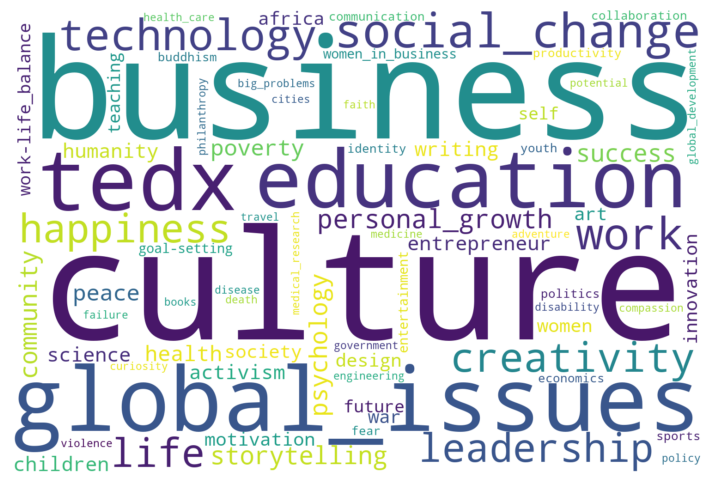

In [112]:
from wordcloud import WordCloud

wordcloud = WordCloud(background_color='white',
                      width=1500,
                      height=1000
                      ).generate_from_frequencies(frequent_tags)

plt.figure(figsize=(9,6))

plt.imshow(wordcloud, interpolation='bilinear')
# Napomena: interpolacija čini sliku jasnijom
# različite opcije za interpolacija:
# https://matplotlib.org/gallery/images_contours_and_fields/interpolation_methods.html


plt.axis('off')
plt.show()